In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
from IPython.display import Audio, display

print(" All libraries imported successfully!")
print(f"   Librosa version  : {librosa.__version__}")
print(f"   NumPy version    : {np.__version__}")
print(f"   Matplotlib version: {plt.matplotlib.__version__}")

 All libraries imported successfully!
   Librosa version  : 0.11.0
   NumPy version    : 2.4.4
   Matplotlib version: 3.10.9


In [2]:
data_root = Path("../data/for-2seconds")
# Individual split paths
train_real = data_root / "training"    / "real"
train_fake = data_root / "training"    / "fake"
val_real   = data_root / "validation"  / "real"
val_fake   = data_root / "validation"  / "fake"
test_real  = data_root / "testing"     / "real"
test_fake  = data_root / "testing"     / "fake"

processed_root = Path("../data/processsed")
result_dir = Path("../results")
result_dir.mkdir(parents=True, exist_ok=True)

# verify paths

print("Checking dataset paths...")
print()

paths_to_check = {
    "Training real" : train_real,
    "Training fake" : train_fake,
    "Validation real": val_real,
    "Validation fake": val_fake,
    "Testing real"   : test_real,
    "Testing fake"   : test_fake,
}
all_good = True
for name, path in paths_to_check.items():
    exists = path.exists()
    count = len(list(path.glob("*.wav"))) if exists else 0
    status = "✅" if exists else "❌"
    print(f"  {status}. {name:<20} -> {str(path):<55}  ({count} .wav files)")
    if not exists:
        all_good = False
print()
if all_good:
    print("All paths found! You are ready to start.")
else:
    print("Some paths are missing. Check that your dataset is in the right folder.")


Checking dataset paths...

  ✅. Training real        -> ../data/for-2seconds/training/real                       (6978 .wav files)
  ✅. Training fake        -> ../data/for-2seconds/training/fake                       (6978 .wav files)
  ✅. Validation real      -> ../data/for-2seconds/validation/real                     (1413 .wav files)
  ✅. Validation fake      -> ../data/for-2seconds/validation/fake                     (1413 .wav files)
  ✅. Testing real         -> ../data/for-2seconds/testing/real                        (544 .wav files)
  ✅. Testing fake         -> ../data/for-2seconds/testing/fake                        (544 .wav files)

All paths found! You are ready to start.


In [3]:
def count_files(folder_path, extension="*.wav"):
    """Count files with given extension in a folder."""
    return len(list(Path(folder_path).glob(extension)))

print("Dataset Summary")
print("=" * 50)

splits = {
    "Training"  : (train_real,  train_fake),
    "Validation": (val_real,    val_fake),
    "Testing"   : (test_real,   test_fake),
}

total_real = 0
total_fake = 0

for split_name, (real_path, fake_path) in splits.items():
    real_count = count_files(real_path)
    fake_count = count_files(fake_path)
    total      = real_count + fake_count
    total_real += real_count
    total_fake += fake_count

    balance = "\Balanced" if abs(real_count - fake_count) < total * 0.1 else "Imbalanced"
    print(f"\n  {split_name}")
    print(f"    Real  : {real_count:>6,} files")
    print(f"    Fake  : {fake_count:>6,} files")
    print(f"    Total : {total:>6,} files  {balance}")

grand_total = total_real + total_fake
print(f"\n{'=' * 50}")
print(f"  Grand Total")
print(f"    Real  : {total_real:>6,} files")
print(f"    Fake  : {total_fake:>6,} files")
print(f"    Total : {grand_total:>6,} files")

Dataset Summary

  Training
    Real  :  6,978 files
    Fake  :  6,978 files
    Total : 13,956 files  \Balanced

  Validation
    Real  :  1,413 files
    Fake  :  1,413 files
    Total :  2,826 files  \Balanced

  Testing
    Real  :    544 files
    Fake  :    544 files
    Total :  1,088 files  \Balanced

  Grand Total
    Real  :  8,935 files
    Fake  :  8,935 files
    Total : 17,870 files


<>:24: SyntaxWarning: invalid escape sequence '\B'
<>:24: SyntaxWarning: invalid escape sequence '\B'
/var/folders/8_/rc86fcvj797fl8rv2f5n3mm40000gn/T/ipykernel_47900/214181842.py:24: SyntaxWarning: invalid escape sequence '\B'
  balance = "\Balanced" if abs(real_count - fake_count) < total * 0.1 else "Imbalanced"


In [4]:
# Get the first real and fake audio files from training set
real_files = sorted(train_real.glob("*.wav"))
fake_files = sorted(train_fake.glob("*.wav"))

if not real_files or not fake_files:
    print(" No audio files found! Check your DATA_ROOT path in Cell 2.")
else:
    # Pick the first file from each
    sample_real_path = real_files[0]
    sample_fake_path = fake_files[0]

    y_real, sr_real = librosa.load(sample_real_path, duration=2, sr=None)
    y_fake, sr_fake = librosa.load(sample_fake_path, duration=2, sr=None)

    print(" Real Audio File")
    print(f"   File          : {sample_real_path.name}")
    print(f"   Sample rate   : {sr_real} Hz  (measurements per second)")
    print(f"   Total samples : {len(y_real):,} numbers in the array")
    print(f"   Duration      : {len(y_real)/sr_real:.3f} seconds")
    print(f"   Data range    : min={y_real.min():.4f}, max={y_real.max():.4f}")
    print(f"   First 8 values: {y_real[:8]}")
    print()
    print(" Fake Audio File")
    print(f"   File          : {sample_fake_path.name}")
    print(f"   Sample rate   : {sr_fake} Hz")
    print(f"   Total samples : {len(y_fake):,} numbers in the array")
    print(f"   Duration      : {len(y_fake)/sr_fake:.3f} seconds")
    print(f"   Data range    : min={y_fake.min():.4f}, max={y_fake.max():.4f}")
    print(f"   First 8 values: {y_fake[:8]}")

 Real Audio File
   File          : file1000.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
   Sample rate   : 16000 Hz  (measurements per second)
   Total samples : 32,000 numbers in the array
   Duration      : 2.000 seconds
   Data range    : min=-0.4355, max=0.6921
   First 8 values: [-0.08306885 -0.08206177 -0.08093262 -0.07876587 -0.07571411 -0.07217407
 -0.06808472 -0.06268311]

 Fake Audio File
   File          : file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
   Sample rate   : 16000 Hz
   Total samples : 32,000 numbers in the array
   Duration      : 2.000 seconds
   Data range    : min=-0.9473, max=1.0000
   First 8 values: [ 0.10552979  0.11013794  0.00952148 -0.03131104 -0.05105591 -0.0557251
  0.00619507  0.06167603]


In [5]:
from IPython.display import Audio, display

print(" REAL voice — listen carefully:")
display(Audio(data=y_real, rate=sr_real))

print()
print(" FAKE AI-generated voice — listen for subtle differences:")
display(Audio(data=y_fake, rate=sr_fake))

print()
print("Notice: Can you hear the difference? Your CNN will learn to detect")
print("differences that are often TOO SUBTLE for human ears to catch.")

 REAL voice — listen carefully:



 FAKE AI-generated voice — listen for subtle differences:



Notice: Can you hear the difference? Your CNN will learn to detect
differences that are often TOO SUBTLE for human ears to catch.


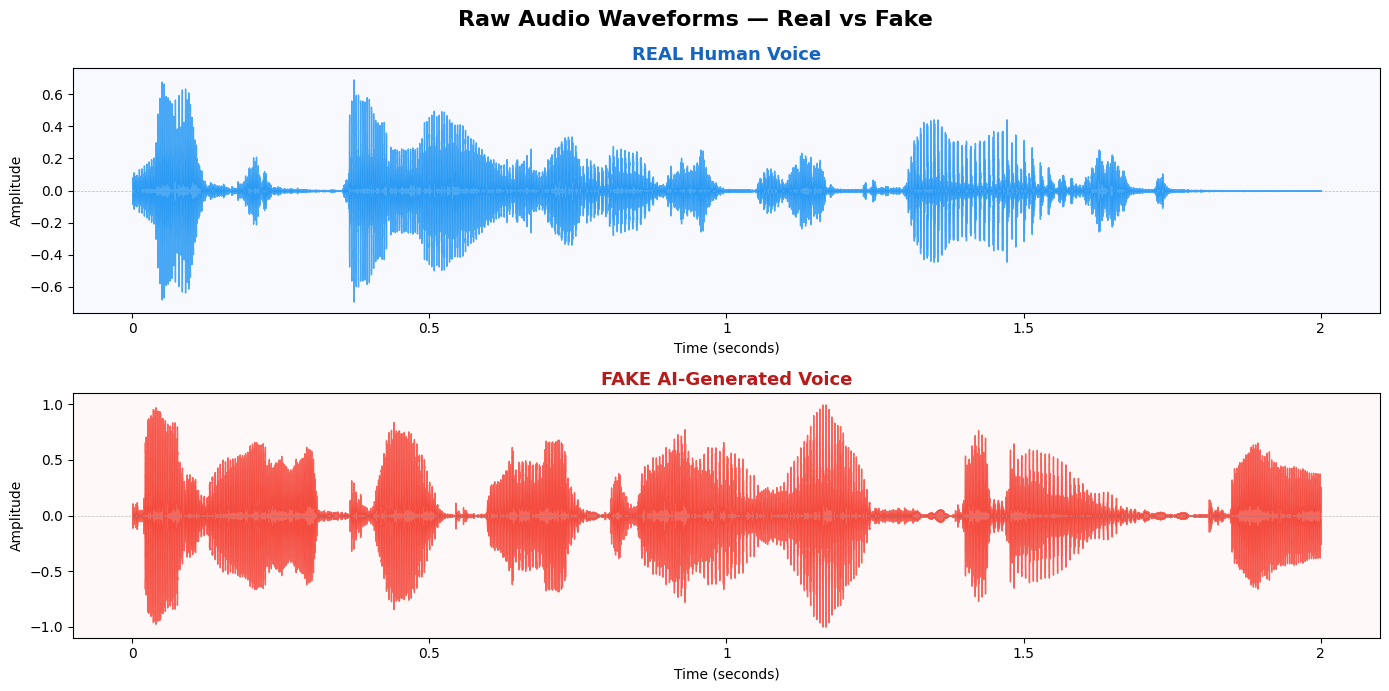

 Saved to: ../results/01_real_vs_fake_waveforms.png

    Observation: Notice how similar the two waveforms look.
    This is exactly why raw waveforms are NOT enough to detect deepfakes.
    We need spectrograms to see the deeper frequency patterns.


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Raw Audio Waveforms — Real vs Fake", fontsize=16, fontweight="bold", y=0.98)

# ── Plot real waveform ────────────────────────────────────────────────────
librosa.display.waveshow(y_real, sr=sr_real, ax=axes[0], color="#2196F3", alpha=0.8)
axes[0].set_title("REAL Human Voice", fontsize=13, color="#1565C0", fontweight="bold")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")
axes[0].set_facecolor("#F8F9FF")
axes[0].axhline(y=0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

# ── Plot fake waveform ────────────────────────────────────────────────────
librosa.display.waveshow(y_fake, sr=sr_fake, ax=axes[1], color="#F44336", alpha=0.8)
axes[1].set_title("FAKE AI-Generated Voice", fontsize=13, color="#B71C1C", fontweight="bold")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")
axes[1].set_facecolor("#FFF8F8")
axes[1].axhline(y=0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

plt.tight_layout()
save_path = result_dir / "01_real_vs_fake_waveforms.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f" Saved to: {save_path}")
print()
print("    Observation: Notice how similar the two waveforms look.")
print("    This is exactly why raw waveforms are NOT enough to detect deepfakes.")
print("    We need spectrograms to see the deeper frequency patterns.")

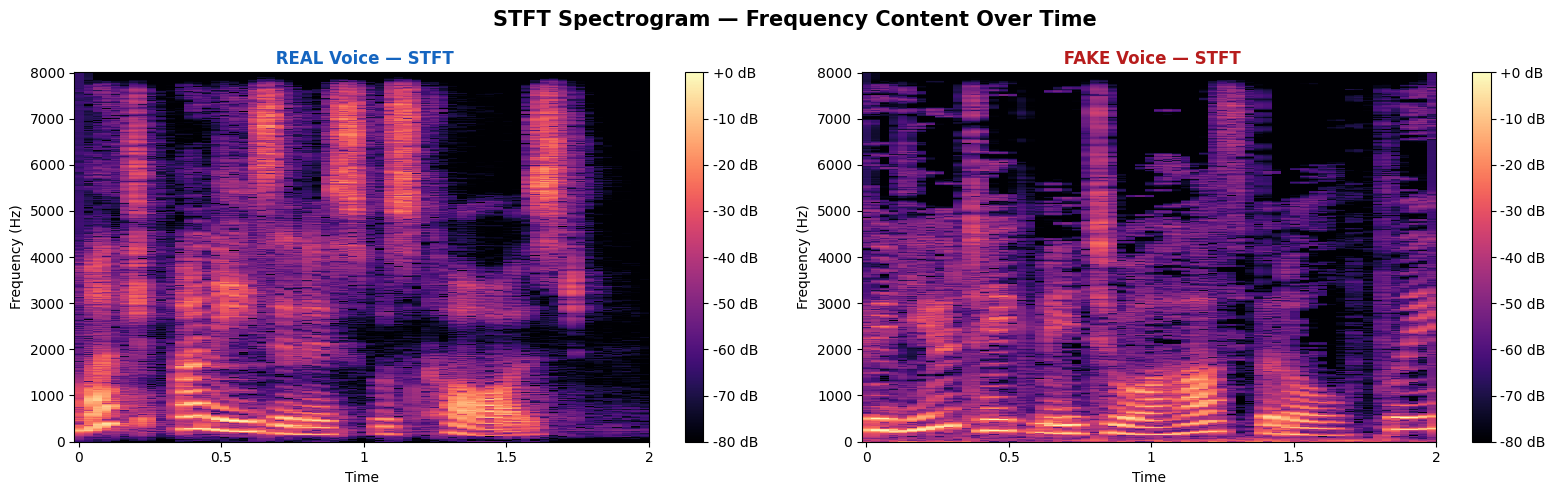

 Saved to: ../results/02_stft_comparison.png

 Shape of STFT matrix (real): (1025, 63)
   This means 1025 frequency bins across 63 time frames

  Now you can start to see texture differences between real and fake!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("STFT Spectrogram — Frequency Content Over Time", fontsize=15, fontweight="bold")

# Compute STFT for real audio
# n_fft = size of each FFT window (2048 is standard)
# hop_length = how many samples to skip between windows (512 is standard)
D_real = librosa.stft(y_real, n_fft=2048, hop_length=512)
D_real_db = librosa.amplitude_to_db(np.abs(D_real), ref=np.max)

# Compute STFT for fake audio
D_fake = librosa.stft(y_fake, n_fft=2048, hop_length=512)
D_fake_db = librosa.amplitude_to_db(np.abs(D_fake), ref=np.max)

# Plot real STFT
img1 = librosa.display.specshow(
    D_real_db, sr=sr_real, hop_length=512,
    x_axis="time", y_axis="hz", ax=axes[0]
)
axes[0].set_title(" REAL Voice — STFT", fontsize=12, color="#1565C0", fontweight="bold")
axes[0].set_ylabel("Frequency (Hz)")
plt.colorbar(img1, ax=axes[0], format="%+2.0f dB")

# Plot fake STFT
img2 = librosa.display.specshow(
    D_fake_db, sr=sr_fake, hop_length=512,
    x_axis="time", y_axis="hz", ax=axes[1]
)
axes[1].set_title(" FAKE Voice — STFT", fontsize=12, color="#B71C1C", fontweight="bold")
axes[1].set_ylabel("Frequency (Hz)")
plt.colorbar(img2, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
save_path = result_dir / "02_stft_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f" Saved to: {save_path}")
print()
print(f" Shape of STFT matrix (real): {D_real.shape}")
print(f"   This means {D_real.shape[0]} frequency bins across {D_real.shape[1]} time frames")
print()
print("  Now you can start to see texture differences between real and fake!")

Mel Spectrogram shapes:
   Real: (128, 63)  → 128 freq bands × 63 time frames
   Fake: (128, 63)  → 128 freq bands × 63 time frames



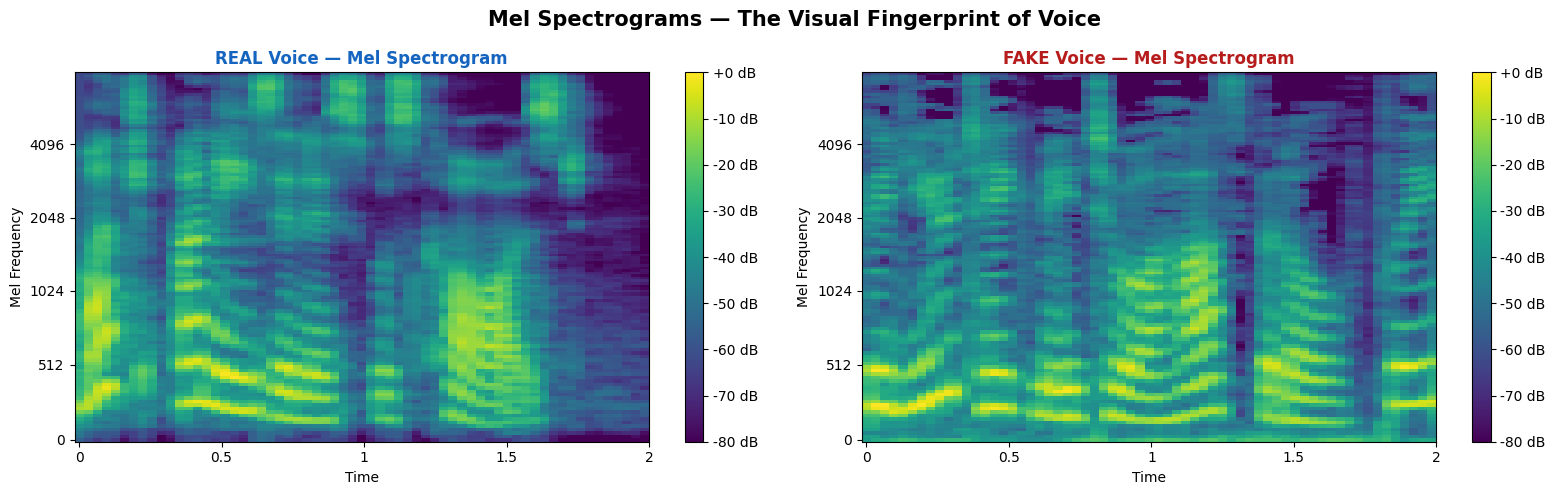

Saved to: ../results/03_mel_spectrogram_comparison.png

    THIS is what your CNN will learn from.
    Notice how the texture and pattern differs between real and fake.
    Real voices have more natural, irregular harmonic patterns.
    Fake voices often show smoother, more uniform frequency distributions.


In [10]:
# Generate Mel Spectrograms
# n_mels=128 means we use 128 mel frequency bands
mel_real = librosa.feature.melspectrogram(y=y_real, sr=sr_real, n_mels=128)
mel_fake = librosa.feature.melspectrogram(y=y_fake, sr=sr_fake, n_mels=128)

# Convert to decibels (log scale — matches human hearing perception)
mel_real_db = librosa.power_to_db(mel_real, ref=np.max)
mel_fake_db = librosa.power_to_db(mel_fake, ref=np.max)

print("Mel Spectrogram shapes:")
print(f"   Real: {mel_real_db.shape}  → {mel_real_db.shape[0]} freq bands × {mel_real_db.shape[1]} time frames")
print(f"   Fake: {mel_fake_db.shape}  → {mel_fake_db.shape[0]} freq bands × {mel_fake_db.shape[1]} time frames")
print()

# ── Plot side by side ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Mel Spectrograms — The Visual Fingerprint of Voice",
             fontsize=15, fontweight="bold")

# Real Mel Spectrogram
img1 = librosa.display.specshow(
    mel_real_db, sr=sr_real,
    x_axis="time", y_axis="mel",
    ax=axes[0], cmap="viridis"
)
axes[0].set_title("REAL Voice — Mel Spectrogram",
                  fontsize=12, color="#1565C0", fontweight="bold")
axes[0].set_ylabel("Mel Frequency")
plt.colorbar(img1, ax=axes[0], format="%+2.0f dB")

# Fake Mel Spectrogram
img2 = librosa.display.specshow(
    mel_fake_db, sr=sr_fake,
    x_axis="time", y_axis="mel",
    ax=axes[1], cmap="viridis"
)
axes[1].set_title("FAKE Voice — Mel Spectrogram",
                  fontsize=12, color="#B71C1C", fontweight="bold")
axes[1].set_ylabel("Mel Frequency")
plt.colorbar(img2, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
save_path = result_dir/ "03_mel_spectrogram_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to: {save_path}")
print()
print("    THIS is what your CNN will learn from.")
print("    Notice how the texture and pattern differs between real and fake.")
print("    Real voices have more natural, irregular harmonic patterns.")
print("    Fake voices often show smoother, more uniform frequency distributions.")

/var/folders/8_/rc86fcvj797fl8rv2f5n3mm40000gn/T/ipykernel_47900/4244652280.py:33: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8_/rc86fcvj797fl8rv2f5n3mm40000gn/T/ipykernel_47900/4244652280.py:35: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
/Users/surabhi/Desktop/vocal-armor-engine/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


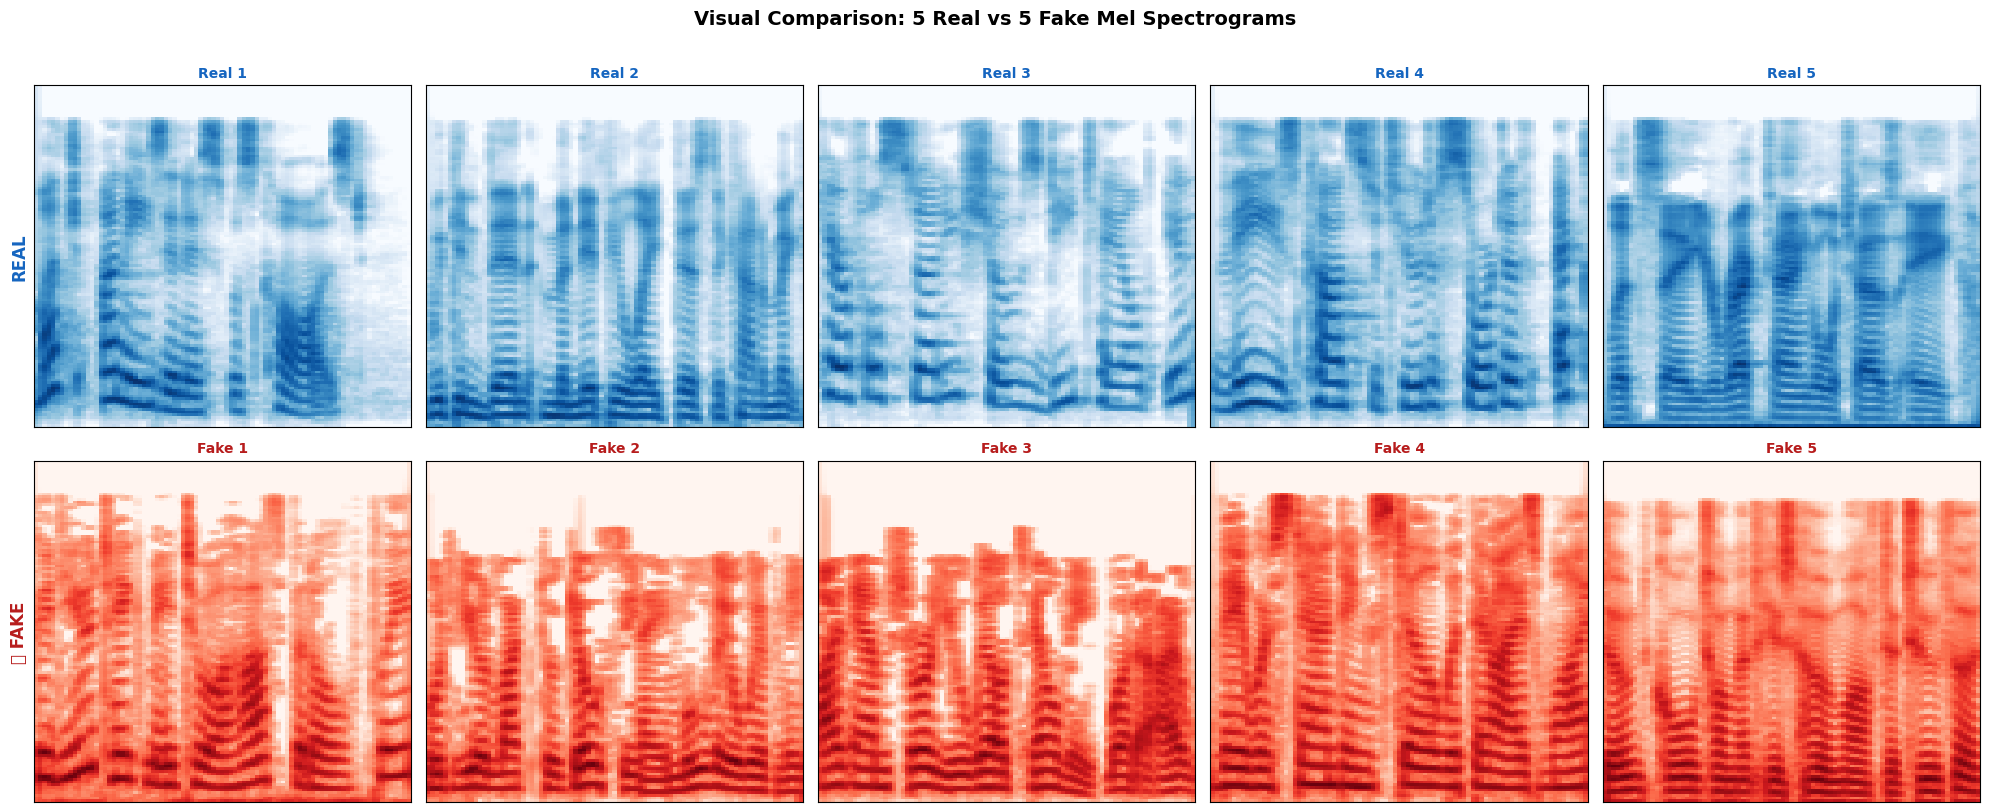

Saved to: ../results/04_real_vs_fake_grid.png


In [11]:
N = 5  # Number of samples to compare

fig, axes = plt.subplots(2, N, figsize=(N * 4, 8))
fig.suptitle(f"Visual Comparison: {N} Real vs {N} Fake Mel Spectrograms",
             fontsize=14, fontweight="bold", y=1.01)

def get_mel_db(audio_path, duration=2):
    """Load audio and return Mel Spectrogram in dB."""
    y, sr = librosa.load(audio_path, duration=duration, sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    return librosa.power_to_db(mel, ref=np.max), sr

# ── Top row: Real samples ─────────────────────────────────────────────────
for i, audio_path in enumerate(sorted(train_real.glob("*.wav"))[:N]):
    mel_db, sr = get_mel_db(audio_path)
    librosa.display.specshow(mel_db, sr=sr, ax=axes[0, i], cmap="Blues")
    axes[0, i].set_title(f"Real {i+1}", fontsize=10, color="#1565C0", fontweight="bold")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    if i == 0:
        axes[0, i].set_ylabel("REAL", fontsize=12, color="#1565C0", fontweight="bold")

# ── Bottom row: Fake samples ──────────────────────────────────────────────
for i, audio_path in enumerate(sorted(train_fake.glob("*.wav"))[:N]):
    mel_db, sr = get_mel_db(audio_path)
    librosa.display.specshow(mel_db, sr=sr, ax=axes[1, i], cmap="Reds")
    axes[1, i].set_title(f"Fake {i+1}", fontsize=10, color="#B71C1C", fontweight="bold")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
    if i == 0:
        axes[1, i].set_ylabel("🤖 FAKE", fontsize=12, color="#B71C1C", fontweight="bold")

plt.tight_layout()
save_path = result_dir / "04_real_vs_fake_grid.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to: {save_path}")

In [12]:
def extract_features(audio_path, duration=2):
    """Extract key statistical features from an audio file."""
    y, sr = librosa.load(audio_path, duration=duration, sr=22050)

    rms             = librosa.feature.rms(y=y)[0].mean()
    zcr             = librosa.feature.zero_crossing_rate(y)[0].mean()
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0].mean()
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0].mean()

    return {
        "rms"               : float(rms),
        "zero_crossing_rate": float(zcr),
        "spectral_centroid" : float(spectral_centroid),
        "spectral_bandwidth": float(spectral_bandwidth),
        "std_amplitude"     : float(np.std(y)),
    }

# Sample 20 real and 20 fake files for analysis
SAMPLE_SIZE = 20

real_features = [extract_features(p) for p in sorted(train_real.glob("*.wav"))[:SAMPLE_SIZE]]
fake_features = [extract_features(p) for p in sorted(train_fake.glob("*.wav"))[:SAMPLE_SIZE]]

feature_names = list(real_features[0].keys())

print(f"{'Feature':<25} {'Real (avg)':>12} {'Fake (avg)':>12} {'Diff %':>10}")
print("-" * 62)

for feat in feature_names:
    real_avg = np.mean([f[feat] for f in real_features])
    fake_avg = np.mean([f[feat] for f in fake_features])
    diff_pct = abs(real_avg - fake_avg) / (abs(real_avg) + 1e-9) * 100
    marker   = " ← notable" if diff_pct > 15 else ""
    print(f"{feat:<25} {real_avg:>12.4f} {fake_avg:>12.4f} {diff_pct:>9.1f}%{marker}")

print()
print("Features with 'notable' difference give the CNN useful signal to learn from.")

Feature                     Real (avg)   Fake (avg)     Diff %
--------------------------------------------------------------
rms                             0.1177       0.1549      31.6% ← notable
zero_crossing_rate              0.1072       0.1117       4.2%
spectral_centroid            1831.9865    1658.7979       9.5%
spectral_bandwidth           1512.3539    1405.3771       7.1%
std_amplitude                   0.1288       0.1753      36.1% ← notable

Features with 'notable' difference give the CNN useful signal to learn from.


Function works correctly!
   Saved test image to: ../results/test_spectrogram_output.png
   Image shape (pixels): (200, 200, 4)


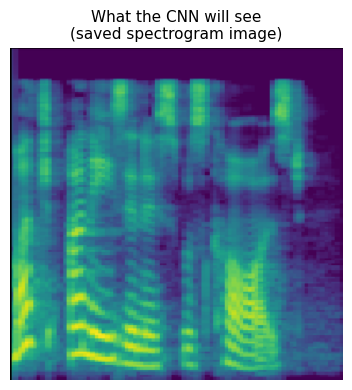

In [13]:
def audio_to_spectrogram_image(audio_path, save_path, duration=2, n_mels=128, sr_target=22050):
    """Convert a single audio file to a Mel Spectrogram image and save it."""
    try:
        # Step 1: Load audio file and resample to standard rate
        y, sr = librosa.load(audio_path, duration=duration, sr=sr_target)

        # Step 2: Handle edge case — file might be shorter than duration
        # Pad with zeros if audio is too short
        expected_length = int(sr_target * duration)
        if len(y) < expected_length:
            y = np.pad(y, (0, expected_length - len(y)))

        # Step 3: Compute Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)

        # Step 4: Convert to dB scale
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Step 5: Save as image — no axes, no whitespace, pure spectrogram
        plt.figure(figsize=(2, 2))          # 2x2 inches
        plt.axes([0, 0, 1, 1])             # axes fill entire figure (no margins)
        librosa.display.specshow(mel_db, sr=sr, cmap="viridis")
        plt.savefig(save_path, dpi=100)     # 100 dpi × 2 inch = 200×200 pixels
        plt.close()                         # IMPORTANT: close to free memory

        return True

    except Exception as e:
        print(f"Error processing {Path(audio_path).name}: {e}")
        return False


# ── Test it on one file ───────────────────────────────────────────────────
test_output_path = result_dir / "test_spectrogram_output.png"
success = audio_to_spectrogram_image(
    audio_path  = sample_real_path,
    save_path   = test_output_path
)

if success:
    print("Function works correctly!")
    print(f"   Saved test image to: {test_output_path}")

    # Show what the saved image looks like
    saved_img = plt.imread(str(test_output_path))
    print(f"   Image shape (pixels): {saved_img.shape}")

    plt.figure(figsize=(4, 4))
    plt.imshow(saved_img)
    plt.title("What the CNN will see\n(saved spectrogram image)", fontsize=11)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Function failed. Check the error message above.")

In [14]:
# All splits and labels to process
SPLITS = [
    ("training",   "real",  train_real),
    ("training",   "fake",  train_fake),
    ("validation", "real",  val_real),
    ("validation", "fake",  val_fake),
    ("testing",    "real",  test_real),
    ("testing",    "fake",  test_fake),
]

overall_success = 0
overall_fail    = 0
overall_skip    = 0

for split_name, label, input_dir in SPLITS:

    # Create output directory
    output_dir = processed_root / split_name / label
    output_dir.mkdir(parents=True, exist_ok=True)

    # Get all wav files in this folder
    audio_files = sorted(input_dir.glob("*.wav"))

    if not audio_files:
        print(f"No files found in {input_dir}")
        continue

    success_count = 0
    fail_count    = 0
    skip_count    = 0

    print(f"\n Processing {split_name}/{label} — {len(audio_files):,} files")

    for audio_file in tqdm(audio_files, desc=f"  {split_name}/{label}", unit="file"):

        save_path = output_dir / f"{audio_file.stem}.png"

        # Skip if already processed (allows resuming after crash)
        if save_path.exists():
            skip_count += 1
            continue

        # Convert audio to spectrogram image
        if audio_to_spectrogram_image(audio_file, save_path):
            success_count += 1
        else:
            fail_count += 1

    print(f"   Converted: {success_count:,}  |    Skipped: {skip_count:,}  |   Failed: {fail_count}")

    overall_success += success_count
    overall_fail    += fail_count
    overall_skip    += skip_count

print()
print("=" * 55)
print(" DATASET CONVERSION COMPLETE")
print(f"   Total converted : {overall_success:,}")
print(f"   Total skipped   : {overall_skip:,}")
print(f"   Total failed    : {overall_fail}")
print("=" * 55)


 Processing training/real — 6,978 files


  training/real:   3%|▎         | 235/6978 [10:43<5:07:39,  2.74s/file] 


KeyboardInterrupt: 

In [ ]:
print("Processed Dataset Verification")
print("=" * 55)

splits_verify = [
    ("training",   "real"),
    ("training",   "fake"),
    ("validation", "real"),
    ("validation", "fake"),
    ("testing",    "real"),
    ("testing",    "fake"),
]

for split_name, label in splits_verify:
    wav_count  = count_files(data_root / split_name / label, "*.wav")
    png_folder = processed_root / split_name / label
    png_count  = count_files(png_folder, "*.png") if png_folder.exists() else 0
    match      = "✅" if abs(wav_count - png_count) < wav_count * 0.02 else "⚠️"
    print(f"  {match}  {split_name}/{label:<10} WAV: {wav_count:>6,}  PNG: {png_count:>6,}")

# ── Visually verify a few images ─────────────────────────────────────────
print()
print(" Spot-checking spectrogram images...")
print()

sample_images_real = sorted((processed_root / "training" / "real").glob("*.png"))[:4]
sample_images_fake = sorted((processed_root / "training" / "fake").glob("*.png"))[:4]

if sample_images_real and sample_images_fake:
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    fig.suptitle("Spot Check: Processed Spectrogram Images",
                 fontsize=13, fontweight="bold")

    for i, img_path in enumerate(sample_images_real):
        img = plt.imread(str(img_path))
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Real {i+1}", color="#1565C0", fontsize=9, fontweight="bold")
        axes[0, i].axis("off")
    axes[0, 0].set_ylabel(" REAL", color="#1565C0", fontsize=10, fontweight="bold")

    for i, img_path in enumerate(sample_images_fake):
        img = plt.imread(str(img_path))
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"Fake {i+1}", color="#B71C1C", fontsize=9, fontweight="bold")
        axes[1, i].axis("off")
    axes[1, 0].set_ylabel(" FAKE", color="#B71C1C", fontsize=10, fontweight="bold")

    plt.tight_layout()
    save_path = result_dir / "05_processed_images_spotcheck.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to: {save_path}")
else:
    print(" No processed images found yet. Run Cell 12 first.")